# 05 -- CatBoost

Сначала собираю пул из lexical/history/E5, затем сравниваю два набора признаков из 02.
Для каждого запроса оставляю максимум 400 кандидатов. Модель учу на rank_train,
параметры выбираю по dev. Положительные объявления в пул вручную не добавляю.

In [1]:
from pathlib import Path
import sys
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

fu_root = Path.cwd() if (Path.cwd() / 'notebooks').exists() else Path.cwd().parent
import nbformat

# Подключаю только ячейки с функциями; расчеты других ноутбуков не запускаю.
for fu_file in ['02_feature_engineering.ipynb', '03_baselines.ipynb']:
    for fu_cell in nbformat.read(fu_root / 'notebooks' / fu_file, as_version=4).cells:
        if 'definitions' in fu_cell.metadata.get('tags', []):
            exec(fu_cell.source, globals())
fu_out = fu_root / 'outputs'
fu_seed = 143

In [2]:
import joblib
from catboost import CatBoostClassifier

fu_items = pd.read_parquet(fu_out / 'cache/items.parquet')
fu_numeric = pd.read_parquet(fu_out / 'cache/item_features.parquet')
fu_queries = pd.read_parquet(fu_out / 'cache/eval_queries.parquet')
fu_base = pd.read_parquet(fu_out / 'cache/base_pairs.parquet')
fu_truth_all = json.loads((fu_out / 'cache/truth.json').read_text())
fu_dev = fu_queries[fu_queries.split.eq('dev')]
fu_truth_dev = {q: fu_truth_all[q] for q in fu_dev.query_id}
fu_hybrid = json.loads((fu_out / 'models/hybrid.json').read_text())
fu_weights = fu_hybrid['weights']
fu_counts = fu_base.item_id.value_counts().to_dict()
fu_files = [
    fu_out / f'cache/candidates_{s}.parquet'
    for s in ['word', 'char', 'bm25', 'bm25_title', 'history', 'dense', 'adapted']
]
fu_dev_candidates = pd.concat(
    [
        pd.read_parquet(p, filters=[('query_id', 'in', fu_dev.query_id.tolist())])
        for p in fu_files
    ],
    ignore_index=True,
)
fu_embedding_ids = pd.read_parquet(
    fu_out / 'cache/embedding_query_ids.parquet'
).query_id.tolist()
fu_query_array = np.load(fu_out / 'cache/query_embeddings.npy')

In [3]:
fu_query_vectors = dict(zip(fu_embedding_ids, fu_query_array))
fu_item_vectors = np.load(fu_out / 'cache/item_embeddings.npy', mmap_mode='r')

## Добавляет ли dense пользу к hybrid?
Сначала сравниваю fixed RRF с разными dense-весами, затем фиксирую candidate pool для fusion.
Выбираю по среднему warm/cold с долей знакомых текстов из unlabeled benchmark.
Это приближение: условные распределения benchmark все равно могут отличаться.

In [4]:
fu_dense_trials = []
fu_dense_configs = []
for fu_kind in ['dense', 'adapted']:
    for fu_weight in [0.0, 0.5, 1.0, 2.0]:
        fu_w = dict(fu_weights)
        fu_w[fu_kind] = fu_weight
        fu_w[fu_kind + '_local'] = 2 * fu_weight
        fu_p = predictions_from_frame(
            rrf(fu_dev_candidates, fu_w, top_k=100), fu_items, k=100
        )
        fu_r = recall_table(fu_p, fu_truth_dev).merge(
            fu_dev[['query_id', 'regime']], on='query_id'
        )
        fu_s = fu_r.groupby('regime')['recall@50'].mean()
        fu_obj = (
            fu_hybrid['warm_share'] * fu_s['warm']
            + (1 - fu_hybrid['warm_share']) * fu_s['cold']
        )
        fu_dense_trials.append(
            {
                'config': len(fu_dense_configs),
                'dense_kind': fu_kind,
                'dense_weight': fu_weight,
                'warm': fu_s['warm'],
                'cold': fu_s['cold'],
                'objective': fu_obj,
            }
        )
        fu_dense_configs.append(fu_w)

In [5]:
fu_dense_trials = pd.DataFrame(fu_dense_trials)
fu_best_dense = int(
    fu_dense_trials.sort_values(['objective', 'config'], ascending=[False, True]).iloc[
        0
    ]['config']
)
fu_weights = fu_dense_configs[fu_best_dense]
fu_dense_trials.to_csv(fu_out / 'validation/dense_fusion_trials.csv', index=False)
display(fu_dense_trials.sort_values('objective', ascending=False))
write_json(
    {'weights': fu_weights, 'constant': 30, 'pool_size': 400, 'selected_on': 'dev'},
    fu_out / 'models/pool.json',
)

,config,dense_kind,dense_weight,warm,cold,objective
7,7,adapted,2.0,0.759988,0.736014,0.744999
3,3,dense,2.0,0.756571,0.730681,0.740384
2,2,dense,1.0,0.740071,0.720181,0.727636
6,6,adapted,1.0,0.742571,0.717681,0.727010
5,5,adapted,0.5,0.738071,0.711847,0.721676
1,1,dense,0.5,0.736571,0.709972,0.719942
0,0,dense,0.0,0.731905,0.696806,0.709961
4,4,adapted,0.0,0.731905,0.696806,0.709961


In [6]:
fu_feature_summary = []
for fu_split in ['rank_train', 'dev', 'test']:
    fu_q = fu_queries[fu_queries.split.eq(fu_split)]
    fu_c = pd.concat(
        [
            pd.read_parquet(p, filters=[('query_id', 'in', fu_q.query_id.tolist())])
            for p in fu_files
        ],
        ignore_index=True,
    )
    fu_features = candidate_features(
        fu_c,
        fu_q,
        fu_items,
        fu_numeric,
        fu_counts,
        fu_weights,
        fu_query_vectors,
        fu_item_vectors,
        max_candidates=400,
    )
    fu_features.to_parquet(fu_out / f'cache/fusion_{fu_split}.parquet', index=False)
    # Никакой разметки test на этом шаге.
    fu_feature_summary.append(
        {
            'split': fu_split,
            'candidate_rows': len(fu_features),
            'queries_with_candidates': fu_features.query_id.nunique(),
            'all_queries': len(fu_q),
        }
    )

In [7]:
display(pd.DataFrame(fu_feature_summary))
fu_train = pd.read_parquet(fu_out / 'cache/fusion_rank_train.parquet')
fu_dev_features = pd.read_parquet(fu_out / 'cache/fusion_dev.parquet')
fu_ids = fu_items.item_id.to_numpy()
fu_train['target'] = [
    int(fu_ids[p] in fu_truth_all[q]) for q, p in zip(fu_train.query_id, fu_train.pos)
]
fu_dev_features['target'] = [
    int(fu_ids[p] in fu_truth_all[q])
    for q, p in zip(fu_dev_features.query_id, fu_dev_features.pos)
]
fu_positive_groups = fu_train.groupby('query_id').target.sum()
fu_training = fu_train[
    fu_train.query_id.isin(fu_positive_groups[fu_positive_groups.gt(0)].index)
].copy()
fu_columns = feature_columns(fu_training)
fu_group_size = fu_training.groupby('query_id').target.transform('size')
fu_npos = fu_training.groupby('query_id').target.transform('sum')
# Положительная и неразмеченная часть каждой группы имеют одинаковый суммарный вес.
fu_sample_weight = np.where(
    fu_training.target.eq(1),
    0.5 / fu_npos,
    0.5 / (fu_group_size - fu_npos).clip(lower=1),
)
fu_sample_weight = fu_sample_weight / fu_sample_weight.mean()
fu_x = model_matrix(fu_training, fu_columns)
fu_xdev = model_matrix(fu_dev_features, fu_columns)
print(
    'Обучающих групп без найденного позитива:',
    int(fu_positive_groups.eq(0).sum()),
    'из',
    len(fu_positive_groups),
)

,split,candidate_rows,queries_with_candidates,all_queries
0,rank_train,1731281,4400,4400
1,dev,784839,2000,2000
2,test,785570,2000,2000


Обучающих групп без найденного позитива: 520 из 4400


In [8]:
write_json(
    {
        'features': fu_columns,
        'train_queries': fu_training.query_id.nunique(),
        'train_rows': len(fu_training),
        'zero_positive_train_groups': int(fu_positive_groups.eq(0).sum()),
    },
    fu_out / 'models/fusion_features.json',
)

In [9]:
fu_model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.07,
    loss_function='Logloss',
    l2_leaf_reg=5,
    random_seed=fu_seed,
    thread_count=4,
    allow_writing_files=False,
    verbose=100,
)
fu_model.fit(fu_x, fu_training.target, sample_weight=fu_sample_weight)
fu_choices = []
fu_dev_predictions = {}
fu_rrf_pred = predictions_from_frame(
    rrf(fu_dev_candidates, fu_weights, top_k=100), fu_items, k=100
)
fu_dev_predictions['rrf'] = fu_rrf_pred
for fu_trees in [150, 300, 500]:
    fu_scored = fu_dev_features[['query_id', 'pos']].copy()
    fu_scored['score'] = fu_model.predict_proba(fu_xdev, ntree_end=fu_trees)[:, 1]
    fu_dev_predictions[f'catboost_{fu_trees}'] = predictions_from_frame(
        fu_scored, fu_items, score='score', k=100
    )
for fu_name, fu_pred in fu_dev_predictions.items():
    fu_result = recall_table(fu_pred, fu_truth_dev).merge(
        fu_dev[['query_id', 'regime']], on='query_id'
    )
    fu_scores = fu_result.groupby('regime')['recall@50'].mean()
    fu_choices.append(
        {
            'model': fu_name,
            'warm': fu_scores['warm'],
            'cold': fu_scores['cold'],
            'objective': fu_hybrid['warm_share'] * fu_scores['warm']
            + (1 - fu_hybrid['warm_share']) * fu_scores['cold'],
        }
    )

0:	learn: 0.6258354	total: 206ms	remaining: 1m 42s


100:	learn: 0.2026389	total: 14.6s	remaining: 57.8s


200:	learn: 0.1805950	total: 28.4s	remaining: 42.2s


300:	learn: 0.1560416	total: 42.3s	remaining: 28s


400:	learn: 0.1370576	total: 56.4s	remaining: 13.9s


499:	learn: 0.1222083	total: 1m 10s	remaining: 0us


In [10]:
fu_choices = pd.DataFrame(fu_choices)
fu_selected = (
    fu_choices.sort_values(['objective', 'model'], ascending=[False, True])
    .iloc[0]
    .model
)
fu_ntree = (
    int(fu_selected.rsplit('_', 1)[1]) if fu_selected.startswith('catboost') else 500
)
fu_model.save_model(str(fu_out / 'models/fusion.cbm'))
write_json(
    {
        'method': fu_selected,
        'ntree': fu_ntree,
        'selected_on': 'dev',
        'test_opened': False,
        'pool_size': 400,
        'weights': fu_weights,
    },
    fu_out / 'models/selected.json',
)
fu_choices.to_csv(fu_out / 'validation/model_selection_dev.csv', index=False)
display(fu_choices.sort_values('objective', ascending=False))

,model,warm,cold,objective
2,catboost_300,0.809536,0.800639,0.803973
1,catboost_150,0.814286,0.792472,0.800648
3,catboost_500,0.810179,0.793639,0.799838
0,rrf,0.759988,0.736014,0.744999


## Feature importance и permutation ablation
Gain importance описывает использование признака деревьями, не причинное влияние на выбор пользователя.
Permutation перемешивает признаки между кандидатами внутри каждого запроса: нарушает соответствие item--feature,
но сохраняет распределение выдачи. Оцениваю падение macro Recall@50 на development.

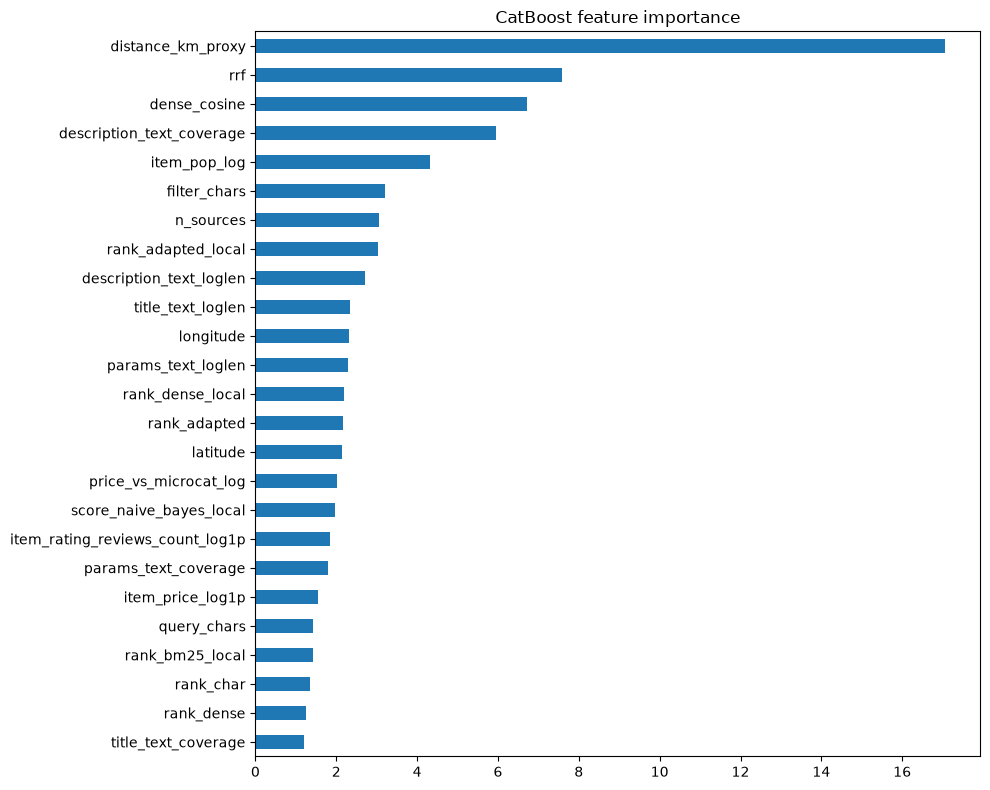

In [11]:
fu_importance = pd.Series(fu_model.feature_importances_, index=fu_columns).sort_values(
    ascending=False
)
fu_importance.to_csv(
    fu_out / 'validation/feature_importance.csv', header=['importance']
)
fu_importance.head(25).sort_values().plot.barh(
    figsize=(10, 8), title='CatBoost feature importance'
)
plt.tight_layout()
plt.savefig(fu_out / 'figures/feature_importance.png', dpi=150)
plt.show()
fu_perm_queries = (
    fu_dev.groupby('regime', group_keys=False)
    .sample(n=150, random_state=fu_seed)
    .query_id.tolist()
)
fu_perm_frame = fu_dev_features[
    fu_dev_features.query_id.isin(fu_perm_queries)
].reset_index(drop=True)
fu_perm_truth = {q: fu_truth_dev[q] for q in fu_perm_queries}
fu_perm_groups = list(fu_perm_frame.groupby('query_id').indices.values())
fu_perm_results = []
fu_rng = np.random.default_rng(fu_seed)
fu_families = {
    'none': [],
    'geography': [
        c
        for c in fu_columns
        if any(
            t in c for t in ['location', 'distance', 'latitude', 'longitude', '_local']
        )
    ],
    'history': [c for c in fu_columns if any(t in c for t in ['history', 'pop'])],
    'dense': [c for c in fu_columns if any(t in c for t in ['dense', 'adapted'])],
    'lexical': [
        c
        for c in fu_columns
        if any(t in c for t in ['bm25', 'word', 'char', 'coverage'])
    ],
    'reputation': [c for c in fu_columns if any(t in c for t in ['rating', 'reviews'])],
    'price': [c for c in fu_columns if 'price' in c],
}

In [12]:
for fu_family, fu_cols in fu_families.items():
    fu_permuted = model_matrix(fu_perm_frame, fu_columns)
    for fu_group in fu_perm_groups:
        if fu_cols:
            fu_permuted.loc[fu_group, fu_cols] = fu_permuted.loc[
                fu_rng.permutation(fu_group), fu_cols
            ].to_numpy()
    fu_scores = fu_model.predict_proba(fu_permuted, ntree_end=fu_ntree)[:, 1]
    fu_pred = predictions_from_frame(
        fu_perm_frame.assign(score=fu_scores), fu_items, score='score', k=100
    )
    fu_perm_results.append(
        {
            'permuted_family': fu_family,
            'recall@50': recall_table(fu_pred, fu_perm_truth)['recall@50'].mean(),
        }
    )
pd.DataFrame(fu_perm_results).to_csv(
    fu_out / 'validation/fusion_permutation_ablations.csv', index=False
)
display(pd.DataFrame(fu_perm_results))

,permuted_family,recall@50
0,none,0.799524
1,geography,0.476349
2,history,0.780000
3,dense,0.726825
4,lexical,0.764683
5,reputation,0.789524
6,price,0.796190


## Дополнительные признаки

Применяю второй набор из 02 к тем же кандидатам. Разметка для расчета не нужна.
Если число строк или порядок пар изменятся, останавливаю расчет.

In [13]:
cb_idf = json.loads((fu_out / 'models/title_idf.json').read_text())
for cb_split in ['rank_train', 'dev', 'test']:
    cb_frame = pd.read_parquet(fu_out / f'cache/fusion_{cb_split}.parquet')
    cb_extended = extra_features(cb_frame, fu_queries, fu_items, cb_idf)
    assert cb_extended[['query_id', 'pos']].equals(cb_frame[['query_id', 'pos']])
    cb_extended.to_parquet(fu_out / f'cache/extended_{cb_split}.parquet', index=False)
cb_extra = [col for col in cb_extended if col not in cb_frame]
cb_audit = cb_extended[cb_extra].agg(['min', 'max']).T
cb_audit['missing_share'] = cb_extended[cb_extra].isna().mean()
assert not np.isinf(cb_extended[cb_extra].to_numpy()).any()
cb_audit.to_csv(fu_out / 'validation/extended_feature_audit.csv')
display(cb_audit)

,min,max,missing_share
title_jaccard,0.000000,1.000000,0.000000
title_precision,0.000000,1.000000,0.000000
title_idf_coverage,0.000000,1.000000,0.000000
title_exact_phrase,0.000000,1.000000,0.000000
title_extra_tokens,0.000000,17.000000,0.000000
filter_param_coverage,0.000000,1.000000,0.000000
query_has_numbers,0.000000,1.000000,0.000000
number_coverage,0.000000,1.000000,0.000000
distance_log1p,0.000000,9.559117,0.120166
remote_distance,0.000000,9.559117,0.120166


In [14]:
cb_out = fu_out
cb_seed = fu_seed

## Обучающие кандидаты

Группы без найденного позитива исключаю только из обучения. На dev они остаются в знаменателе.
Для классификаторов суммарный вес положительной и неразмеченной части каждого запроса одинаковый.
Каталожные ID и target не попадают в матрицу. Масштабирование обучаю только на rank_train.

In [15]:
cb_train = (
    pd.read_parquet(cb_out / 'cache/extended_rank_train.parquet')
    .sort_values(['query_id', 'pos'])
    .reset_index(drop=True)
)
cb_dev = (
    pd.read_parquet(cb_out / 'cache/extended_dev.parquet')
    .sort_values(['query_id', 'pos'])
    .reset_index(drop=True)
)
cb_queries = pd.read_parquet(cb_out / 'cache/eval_queries.parquet')
cb_dev_queries = cb_queries[cb_queries.split.eq('dev')]
cb_items = pd.read_parquet(cb_out / 'cache/items.parquet', columns=['item_id'])
cb_truth = json.loads((cb_out / 'cache/truth.json').read_text())
cb_dev_truth = {q: cb_truth[q] for q in cb_dev_queries.query_id}
cb_ids = cb_items.item_id.to_numpy()
cb_columns = feature_columns(cb_train)
cb_train['target'] = [
    int(cb_ids[p] in cb_truth[q]) for q, p in zip(cb_train.query_id, cb_train.pos)
]
cb_found = cb_train.groupby('query_id').target.transform('sum')
cb_train = cb_train[cb_found.gt(0)].reset_index(drop=True)
cb_npos = cb_train.groupby('query_id').target.transform('sum')
cb_n = cb_train.groupby('query_id').target.transform('size')
cb_weights = np.where(
    cb_train.target.eq(1), 0.5 / cb_npos, 0.5 / (cb_n - cb_npos).clip(lower=1)
)
cb_weights /= cb_weights.mean()
cb_x = model_matrix(cb_train, cb_columns)
cb_xdev = model_matrix(cb_dev, cb_columns)
cb_share = json.loads((cb_out / 'models/hybrid.json').read_text())['warm_share']
cb_results = []
cb_scores = cb_dev[['query_id', 'pos']].copy()
write_json(
    {'features': cb_columns, 'seed': cb_seed}, cb_out / 'models/extended_features.json'
)

In [16]:
def cb_evaluate(name, scores, seconds):
    predictions = predictions_from_frame(
        cb_dev.assign(score=scores), cb_items, score='score', k=100
    )
    per_query = recall_table(predictions, cb_dev_truth).merge(
        cb_dev_queries[['query_id', 'regime']], on='query_id'
    )
    values = per_query.groupby('regime')['recall@50'].mean()
    cb_scores[name] = scores
    cb_results.append(
        {
            'model': name,
            'cold': values['cold'],
            'warm': values['warm'],
            'objective': (1 - cb_share) * values['cold'] + cb_share * values['warm'],
            'fit_seconds': seconds,
        }
    )
    pd.DataFrame(cb_results).to_csv(cb_out / 'validation/models_cb.csv', index=False)
    per_query.to_parquet(cb_out / f'validation/dev_{name}.parquet', index=False)
    print(cb_results[-1], flush=True)

## Контроль: основные 80 признаков

Сначала оцениваю модель на основных признаках. Она обучена только на rank_train.
Сравнение при одинаковых 300 деревьях показывает вклад дополнительных признаков.

In [17]:
cb_original_columns = json.loads((cb_out / 'models/fusion_features.json').read_text())[
    'features'
]
cb_original = CatBoostClassifier().load_model(str(cb_out / 'models/fusion.cbm'))
cb_evaluate(
    'basic_300',
    cb_original.predict_proba(model_matrix(cb_dev, cb_original_columns), ntree_end=300)[
        :, 1
    ],
    0.0,
)

{'model': 'basic_300', 'cold': np.float64(0.8006388888888889), 'warm': np.float64(0.8095357142857144), 'objective': np.float64(0.8039733842150236), 'fit_seconds': 0.0}


## CatBoost с дополнительными признаками

При 300 деревьях меняются только признаки -- сравнение с исходной моделью изолирует их вклад.
Дополнительно проверяю 500 деревьев: больше признаков может потребовать больше шагов обучения.

In [18]:
cb_start = time.perf_counter()
cb_cat = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.07,
    loss_function='Logloss',
    l2_leaf_reg=5,
    random_seed=cb_seed,
    thread_count=4,
    allow_writing_files=False,
    verbose=100,
)
cb_cat.fit(cb_x, cb_train.target, sample_weight=cb_weights)
cb_seconds = time.perf_counter() - cb_start
for cb_trees in [300, 500]:
    cb_evaluate(
        f'extended_{cb_trees}',
        cb_cat.predict_proba(cb_xdev, ntree_end=cb_trees)[:, 1],
        cb_seconds,
    )
cb_cat.save_model(str(cb_out / 'models/extended_catboost.cbm'))

0:	learn: 0.6184632	total: 171ms	remaining: 1m 25s


100:	learn: 0.1946359	total: 16.6s	remaining: 1m 5s


200:	learn: 0.1703205	total: 32.4s	remaining: 48.3s


300:	learn: 0.1444703	total: 48.5s	remaining: 32s


400:	learn: 0.1257953	total: 1m 4s	remaining: 16s


499:	learn: 0.1124963	total: 1m 20s	remaining: 0us


{'model': 'extended_300', 'cold': np.float64(0.8004722222222221), 'warm': np.float64(0.8156785714285715), 'objective': np.float64(0.8061715023693), 'fit_seconds': 81.0799837909999}


{'model': 'extended_500', 'cold': np.float64(0.7924722222222221), 'warm': np.float64(0.8121785714285714), 'objective': np.float64(0.7998580847510292), 'fit_seconds': 81.0799837909999}


In [19]:
cb_scores.to_parquet(cb_out / 'cache/scores_catboost.parquet', index=False)

## Проверка на test

Сравниваю зафиксированные варианты на 300 деревьях. Этот test уже просматривался раньше,
поэтому использую его как дополнительную диагностику, а не новый независимый результат.
Параметры по этой таблице не меняю.

In [20]:
cb_test = pd.read_parquet(cb_out / 'cache/extended_test.parquet')
cb_test_queries = cb_queries[cb_queries.split.eq('test')]
cb_test_truth = {q: cb_truth[q] for q in cb_test_queries.query_id}
cb_holdout = []
for cb_name, cb_model, cb_fields in [
    ('basic_300', cb_original, cb_original_columns),
    ('extended_300', cb_cat, cb_columns),
]:
    cb_values = cb_model.predict_proba(model_matrix(cb_test, cb_fields), ntree_end=300)[
        :, 1
    ]
    cb_predictions = predictions_from_frame(
        cb_test.assign(score=cb_values), cb_items, score='score', k=100
    )
    cb_metrics = recall_table(cb_predictions, cb_test_truth).merge(
        cb_test_queries[['query_id', 'regime']], on='query_id', validate='one_to_one'
    )
    cb_metrics['model'] = cb_name
    cb_holdout.append(cb_metrics)
cb_holdout = pd.concat(cb_holdout, ignore_index=True)
cb_holdout.to_parquet(cb_out / 'validation/holdout_per_query.parquet', index=False)
cb_holdout_summary = cb_holdout.groupby(['model', 'regime']).mean(numeric_only=True)
cb_holdout_summary.to_csv(cb_out / 'validation/holdout.csv')
display(cb_holdout_summary)

cb_selection = json.loads((cb_out / 'models/selected.json').read_text())
cb_selection['test_opened'] = True
cb_selection['test_reused_from_earlier_experiments'] = True
write_json(cb_selection, cb_out / 'models/selected.json')

n_relevant  recall@1  recall@10  recall@20  recall@50  \
model        regime                                                          
basic_300    cold         1.071  0.261167   0.640917   0.720458   0.807542   
             warm         1.207  0.276841   0.651347   0.738822   0.810980   
extended_300 cold         1.071  0.264167   0.646583   0.716583   0.803667   
             warm         1.207  0.276841   0.651147   0.730892   0.808036   

                     recall@100  
model        regime              
basic_300    cold      0.842167  
             warm      0.846876  
extended_300 cold      0.846167  
             warm      0.843136

In [21]:
cb_pool_predictions = predictions_from_frame(cb_test, cb_items, score='rrf', k=400)
cb_ceiling = recall_table(cb_pool_predictions, cb_test_truth, ks=(400,)).merge(
    cb_test_queries[['query_id', 'regime']], on='query_id', validate='one_to_one'
)
cb_ceiling.groupby('regime')['recall@400'].mean().to_csv(
    cb_out / 'validation/holdout_pool_ceiling.csv'
)
cb_slices = pd.read_parquet(cb_out / 'validation/query_slices.parquet')
cb_diagnostic = cb_holdout.merge(
    cb_slices[['query_id', 'cold_item_fraction', 'new_pair_fraction']],
    on='query_id',
    validate='many_to_one',
)
cb_slice_rows = []
for cb_slice, cb_mask in [
    ('all', np.ones(len(cb_diagnostic), dtype=bool)),
    ('all_items_without_history', cb_diagnostic.cold_item_fraction.eq(1)),
    ('all_pairs_new_for_text', cb_diagnostic.new_pair_fraction.eq(1)),
]:
    cb_table = (
        cb_diagnostic[cb_mask]
        .groupby(['model', 'regime'])
        .agg(queries=('query_id', 'size'), recall50=('recall@50', 'mean'))
        .reset_index()
    )
    cb_table['slice'] = cb_slice
    cb_slice_rows.append(cb_table)
cb_slice_table = pd.concat(cb_slice_rows, ignore_index=True)
cb_slice_table.to_csv(cb_out / 'validation/holdout_slices.csv', index=False)
display(cb_slice_table)

,model,regime,queries,recall50,slice
0,basic_300,cold,1000,0.807542,all
1,basic_300,warm,1000,0.810980,all
2,extended_300,cold,1000,0.803667,all
3,extended_300,warm,1000,0.808036,all
4,basic_300,cold,654,0.814730,all_items_without_history
5,basic_300,warm,632,0.823180,all_items_without_history
6,extended_300,cold,654,0.817788,all_items_without_history
7,extended_300,warm,632,0.822389,all_items_without_history
8,basic_300,cold,1000,0.807542,all_pairs_new_for_text
9,basic_300,warm,949,0.810968,all_pairs_new_for_text


## Обучение на всех доступных парах

После сравнения сохраняю отдельную модель для ответа. Локальные метрики после этого
ей не приписываю: в финальное обучение входят все три отложенные части.

In [22]:
su_out = fu_out
su_seed = 143

In [23]:
import joblib

su_items = fu_items
su_numeric = fu_numeric
su_selected = json.loads((su_out / 'models/selected.json').read_text())

## Финальный корпус и переиндексация
Corpus-derived TF-IDF/BM25 допускают использование всей известной коллекции документов.
Здесь беру строки уже обученного индекса только для benchmark; IDF остается обученным на общем каталоге.
Top-k выполняется заново по ограниченной матрице. Это не потеря кандидатов из-за фильтра после retrieval.

In [24]:
su_train_raw, su_bq_raw, su_bi_raw = load_raw()
su_bq = prepare_queries(su_bq_raw)
su_mask = su_items.item_id.isin(su_bi_raw.item_id).to_numpy()
su_positions = np.flatnonzero(su_mask)
su_bitems = su_items.iloc[su_positions].reset_index(drop=True)
su_bnumeric = su_numeric.iloc[su_positions].reset_index(drop=True)
su_centers = su_items.groupby('item_location_id')[
    ['item_latitude', 'item_longitude']
].median()
su_full_pairs = prepare_queries(su_train_raw)
su_full_pairs['item_id'] = su_train_raw.item_id.to_numpy()
su_full_pairs = su_full_pairs.drop_duplicates(['context_key', 'item_id'])
su_index = joblib.load(su_out / 'cache/lexical_index.joblib')
for su_attribute in ['word_matrix', 'bm25', 'overlap', 'title_bm25', 'char_matrix']:
    setattr(su_index, su_attribute, getattr(su_index, su_attribute)[su_positions])
su_candidates = su_index.search(
    su_bq, su_bitems, k=120, methods=['word', 'char', 'bm25', 'bm25_title']
)
su_history = HistoryIndex().fit(su_full_pairs, su_bitems, label_catalog=su_items)
su_history_candidates = su_history.search(su_bq, k=120)
su_candidates = pd.concat([su_candidates, su_history_candidates], ignore_index=True)
# Вектора запросов benchmark рассчитаны в 04 тем же encoder.
su_emb_ids = pd.read_parquet(
    su_out / 'cache/embedding_query_ids.parquet'
).query_id.tolist()
su_qpos = dict(zip(su_emb_ids, range(len(su_emb_ids))))
su_qvectors = np.load(su_out / 'cache/query_embeddings.npy')[
    [su_qpos[q] for q in su_bq.query_id]
]

word: 2452 queries, 17.5s


char: 2452 queries, 7.5s


bm25: 2452 queries, 16.0s


bm25_title: 2452 queries, 1.2s


In [25]:
su_qadapted = np.load(su_out / 'cache/query_embeddings_adapted.npy')[
    [su_qpos[q] for q in su_bq.query_id]
]
su_ivectors = np.array(
    np.load(su_out / 'cache/item_embeddings.npy', mmap_mode='r')[su_positions]
)
su_dense = dense_search(su_qvectors, su_ivectors, su_bq, su_bitems, k=120)
su_adapted = dense_search(su_qadapted, su_ivectors, su_bq, su_bitems, k=120)
su_adapted['source'] = su_adapted.source.str.replace('dense', 'adapted')
su_candidates = pd.concat([su_candidates, su_dense, su_adapted], ignore_index=True)
su_candidates.to_parquet(su_out / 'cache/benchmark_candidates.parquet', index=False)
su_bfeatures = candidate_features(
    su_candidates,
    su_bq,
    su_bitems,
    su_bnumeric,
    su_full_pairs.item_id.value_counts().to_dict(),
    su_selected['weights'],
    dict(zip(su_bq.query_id, su_qvectors)),
    su_ivectors,
    max_candidates=400,
    centers=su_centers,
)

In [26]:
su_bfeatures.to_parquet(su_out / 'cache/benchmark_features.parquet', index=False)
su_bitems[['item_id']].to_parquet(
    su_out / 'cache/benchmark_item_order.parquet', index=False
)

In [27]:
en_root = fu_root
en_out = fu_out
en_seed = 143
en_truth_all = fu_truth_all

In [28]:
en_columns = json.loads((en_out / 'models/extended_features.json').read_text())[
    'features'
]
en_catalog = pd.read_parquet(en_out / 'cache/items.parquet')
en_train = pd.concat(
    [
        pd.read_parquet(en_out / f'cache/extended_{part}.parquet')
        for part in ['rank_train', 'dev', 'test']
    ],
    ignore_index=True,
)
en_ids = en_catalog.item_id.to_numpy()
en_train['target'] = [
    int(en_ids[p] in en_truth_all[q]) for q, p in zip(en_train.query_id, en_train.pos)
]
en_positive = en_train.groupby('query_id').target.transform('sum')
en_train = en_train[en_positive.gt(0)].copy()
en_positive = en_train.groupby('query_id').target.transform('sum')
en_n = en_train.groupby('query_id').target.transform('size')
en_weight = np.where(
    en_train.target.eq(1), 0.5 / en_positive, 0.5 / (en_n - en_positive).clip(lower=1)
)
en_final = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.07,
    loss_function='Logloss',
    l2_leaf_reg=5,
    random_seed=en_seed,
    thread_count=4,
    allow_writing_files=False,
    verbose=100,
)
en_final.fit(
    model_matrix(en_train, en_columns),
    en_train.target,
    sample_weight=en_weight / en_weight.mean(),
)
en_final.save_model(str(en_out / 'models/extended_final.cbm'))
del en_train

0:	learn: 0.6201075	total: 322ms	remaining: 1m 36s


100:	learn: 0.2053228	total: 32.9s	remaining: 1m 4s


200:	learn: 0.1874160	total: 1m 4s	remaining: 31.7s


299:	learn: 0.1710401	total: 1m 34s	remaining: 0us


In [29]:
en_bq = su_bq
en_bitems = su_bitems
en_counts = su_full_pairs.item_id.value_counts().to_dict()

In [30]:
en_frame = su_bfeatures.copy()
en_idf = json.loads((en_out / 'models/title_idf.json').read_text())
en_basic_columns = json.loads((en_out / 'models/fusion_features.json').read_text())[
    'features'
]
en_rank_columns = [col for col in en_basic_columns if col.startswith('rank_')]
en_extended = extra_features(
    en_frame, en_bq, en_bitems, en_idf, rank_columns=en_rank_columns
)
en_frame['extended'] = en_final.predict_proba(model_matrix(en_extended, en_columns))[
    :, 1
]
en_pop = sorted(en_bitems.item_id, key=lambda i: (-en_counts.get(i, 0), i))[:100]

In [31]:
def en_final_predictions(score):
    predictions = predictions_from_frame(
        en_frame.assign(score=score), en_bitems, score='score', k=50
    )
    for query_id in en_bq.query_id:
        top = predictions.get(query_id, [])
        predictions[query_id] = (
            top + [item for item in en_pop if item not in set(top)]
        )[:50]
    return predictions


en_path = en_out / 'submissions/answer_catboost.csv'
en_validation = save_submission(
    en_final_predictions(en_frame.extended), en_bq, en_bitems, en_path
)
write_json(en_validation, en_out / 'submissions/validation_catboost.json')
display(en_validation)

{'rows': 2452, 'min_candidates': 50, 'max_candidates': 50, 'valid': True}

In [32]:
en_frame[['query_id', 'pos', 'extended', 'rrf']].to_parquet(
    en_out / 'cache/benchmark_catboost_scores.parquet', index=False
)

## Вывод

При 300 деревьях дополнительные признаки подняли dev с 0.80397 до 0.80617.
На cold разница почти нулевая, прирост дает warm. На test улучшение не подтвердилось:
0.80367 / 0.80804 против 0.80754 / 0.81098 у основных признаков (cold / warm).
Это повод осторожно относиться к небольшому выигрышу на dev.

answer_catboost.csv построен выбранной по dev конфигурацией на 101 признаке.
Ее закрытый score пока неизвестен. После refit метрики на обучающих частях ей не приписываю.
Далее проверяю линейную модель, другой loss и MLP на том же пуле.